# Network Analysis Sandbox
This notebook loads the stock similarity matrix and builds a network using the logic from `main.py`. Use the cells below to explore the graph structure and run custom analysis.

In [1]:
import sys
import os
import networkx as nx
import pandas as pd
from pathlib import Path

# Add project root to sys.path to allow importing main.py
sys.path.append(os.path.abspath('.'))

# Import the existing build_network function
from main import build_network

# Configuration
output_dir = Path("output")
similarity_file = output_dir / "ticker_similarities.csv"

# Load and process the similarity matrix
if not similarity_file.exists():
    print(f"Error: {similarity_file} not found. Please run data_processor.py first.")
else:
    # Load the similarity matrix
    sim_df = pd.read_csv(similarity_file, index_col=0)

    # Calculate simple cosine distance: d = 1 - s
    cosine_dist = 1.0 - sim_df.values
    dist_df = pd.DataFrame(cosine_dist, index=sim_df.index, columns=sim_df.columns)

    # Build the network using the shared logic
    G = build_network(dist_df)
    print(f"Graph loaded with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Building a dense graph from distance matrix...
Graph built with 2441 nodes and 2978020 edges.
Graph loaded with 2441 nodes and 2978020 edges.


### Basic Visualization and Top Closest Pairs
Identify the stocks that have the lowest cosine distance (and thus highest similarity).

In [2]:
# Display Top 10 Closest Ticker Pairs
print("\nTop 10 Closest Ticker Pairs (by Cosine Distance):")
edges = sorted(G.edges(data=True), key=lambda x: x[2].get("weight", 1.0))

count = 0
for u, v, d in edges:
    if count >= 10:
        break
    print(f"{u} <-> {v}: distance = {d['weight']:.4f}")
    count += 1

count = 0
for u, v, d in edges:
    if count >= 10:
        break
    print(f"{u} <-> {v}: distance = {d['weight']:.4f}")
    count += 1



Top 10 Closest Ticker Pairs (by Cosine Distance):
GOOG <-> GOOGL: distance = 0.0001
LILA <-> LILAK: distance = 0.0035
LBRDA <-> LBRDK: distance = 0.0039
CCL <-> CUK: distance = 0.0048
Z <-> ZG: distance = 0.0052
LBTYA <-> LBTYK: distance = 0.0063
FOX <-> FOXA: distance = 0.0075
UA <-> UAA: distance = 0.0099
NWS <-> NWSA: distance = 0.0114
CENT <-> CENTA: distance = 0.0195
GOOG <-> GOOGL: distance = 0.0001
LILA <-> LILAK: distance = 0.0035
LBRDA <-> LBRDK: distance = 0.0039
CCL <-> CUK: distance = 0.0048
Z <-> ZG: distance = 0.0052
LBTYA <-> LBTYK: distance = 0.0063
FOX <-> FOXA: distance = 0.0075
UA <-> UAA: distance = 0.0099
NWS <-> NWSA: distance = 0.0114
CENT <-> CENTA: distance = 0.0195


In [3]:
# Calculate hubs in the Minimum Spanning Tree (MST)
# T is the MST calculated in the previous cell
T = nx.minimum_spanning_tree(G, weight="weight")

# Get degrees for all nodes in the MST
mst_degrees = dict(T.degree())

# Sort nodes by degree in descending order
top_mst_hubs = sorted(mst_degrees.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 Hub Nodes in the MST (Highest Degree):")
for node, degree in top_mst_hubs:
    print(f"{node}: degree = {degree}")

# Optional: Highlight these hubs in a printout of their neighbors
print("\nConnections for the top MST hub:")
top_hub = top_mst_hubs[0][0]
neighbors = list(T.neighbors(top_hub))
print(f"{top_hub} is connected to: {', '.join(neighbors)}")


Top 5 Hub Nodes in the MST (Highest Degree):
CSQ: degree = 27
ITT: degree = 25
MCO: degree = 18
HAL: degree = 17
FCF: degree = 15

Connections for the top MST hub:
CSQ is connected to: CHW, TY, CHY, ARES, CZR, MCO, ADSK, CNNE, QTWO, FSV, ALGN, AB, SONO, ATRC, FFIV, STN, ATLC, WING, COST, CALX, FTAI, WMG, FWONK, OSPN, TSLA, ORCL, MFIN


In [15]:
import networkx as nx

# 1. Create a threshold (e.g., keep only connections with distance < 0.2)
# Adjust this number based on how many edges you want to keep
threshold = 0.2 
filtered_edges = [(u, v, d) for u, v, d in G.edges(data=True) if d['weight'] < threshold]

# 2. Build a new, thinner graph
G_filtered = nx.Graph()
G_filtered.add_edges_from(filtered_edges)

#If wanted to keep all the original nodes instead of filtering them also
#G_filtered = G.copy() # Keeps all original nodes
#G_filtered.remove_edges_from([(u, v) for u, v, d in G.edges(data=True) if d['distance'] >= threshold])

print(f"Nodes: {G_filtered.number_of_nodes()}, Edges: {G_filtered.number_of_edges()}")

Nodes: 498, Edges: 2153


In [20]:
# This calculates which nodes appear most often on shortest paths
centrality = nx.betweenness_centrality(G_filtered, weight='distance')

# Sort to find the top "Bridge Stocks"
sorted_centrality = sorted(centrality.items(), key=lambda x: x[1], reverse=True)

print("Top 10 Bridge Stocks (Betweenness Centrality):")
for ticker, score in sorted_centrality[:10]:
    print(f"{ticker}: {score:.4f}")

Top 10 Bridge Stocks (Betweenness Centrality):
FITB: 0.0079
CATY: 0.0058
PRU: 0.0058
BAC: 0.0052
ABCB: 0.0048
TCBK: 0.0038
FCF: 0.0036
USB: 0.0032
FRME: 0.0029
BKU: 0.0025


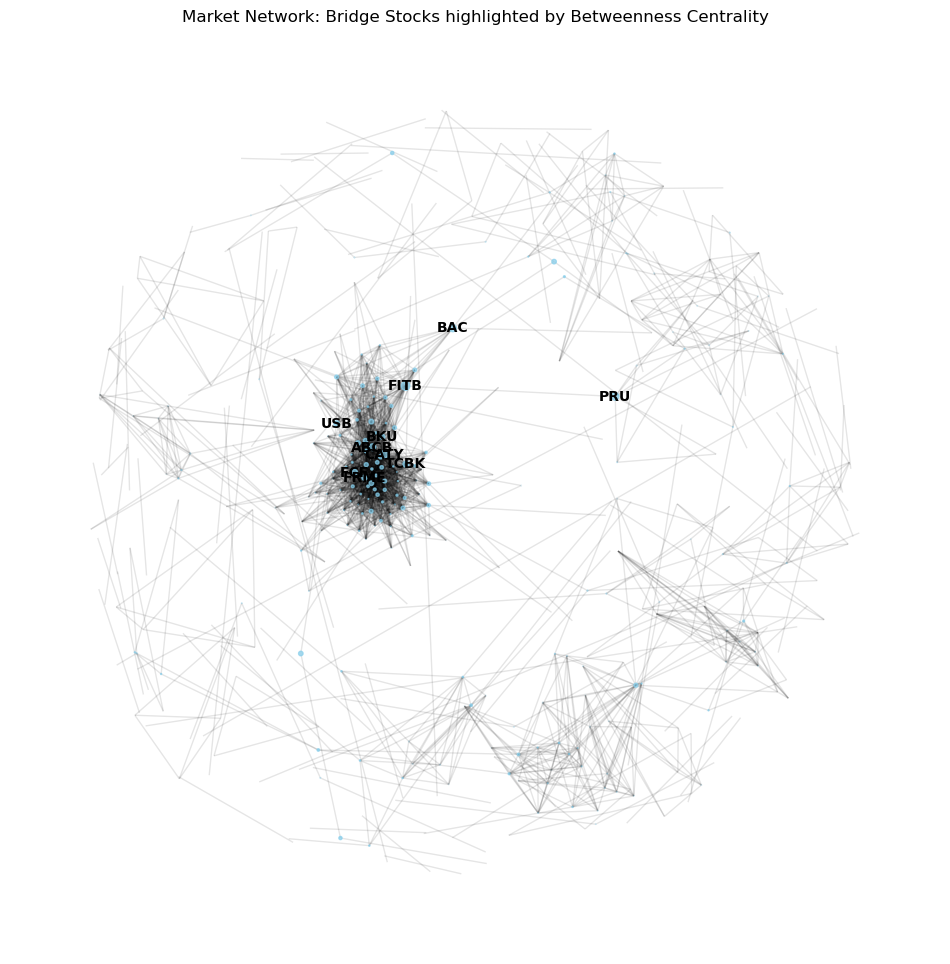

In [19]:
import matplotlib.pyplot as plt

# 1. Set the layout (this can take a few seconds for ~500 nodes)
pos = nx.spring_layout(G_filtered, k=0.15, seed=42)

# 2. Scale node sizes based on centrality scores
# Multiplying by a large number (e.g., 5000) makes the bridges visible
node_sizes = [centrality[node] * 5000 for node in G_filtered.nodes()]

# 3. Plot the network
plt.figure(figsize=(12, 12))
nx.draw_networkx_nodes(G_filtered, pos, node_size=node_sizes, node_color='skyblue', alpha=0.7)
nx.draw_networkx_edges(G_filtered, pos, alpha=0.1) # Keep edges faint to see clusters

# Label only the top 10 bridge stocks to avoid clutter
labels = {ticker: ticker for ticker, _ in sorted_centrality[:10]}
nx.draw_networkx_labels(G_filtered, pos, labels=labels, font_size=10, font_weight='bold')

plt.title("Market Network: Bridge Stocks highlighted by Betweenness Centrality")
plt.axis('off')
plt.savefig("market_network_spring.png", format="PNG", dpi=300, bbox_inches='tight')
plt.show()